# Trabalho 3 - Aprendizagem de Máquina

## Componentes

- Raphael Ramos
- Vitor Gabriel

In [1]:
import pandas as pd
from pathlib import Path


datasets_dir = Path("../data")

air_quality = pd.read_csv(
    datasets_dir / "india_air_quality_daily_2015_to_2020.csv",
    index_col="Date",
    parse_dates=["Date"]
)

air_quality

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,,
2015-01-01,Ahmedabad,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
2015-01-02,Ahmedabad,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2015-01-03,Ahmedabad,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
2015-01-04,Ahmedabad,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
2015-01-05,Ahmedabad,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-27,Visakhapatnam,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
2020-06-28,Visakhapatnam,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
2020-06-29,Visakhapatnam,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory


In [2]:
# Cidades disponíveis para serem analisadas
# cities = air_quality['City'].unique()
cities = [
    "Ahmedabad",
    "Amritsar",
    "Chennai",
    "Delhi",
    "Jaipur",
    "Lucknow",
    "Mumbai",
    "Patna",
]
cities

['Ahmedabad',
 'Amritsar',
 'Chennai',
 'Delhi',
 'Jaipur',
 'Lucknow',
 'Mumbai',
 'Patna']

In [3]:
# Escolher uma cidade para fazer a previsão do AQI
city = cities[3]

# Filtrar o Dataframe com os dados temporais apenas dessa cidade
air_quality_filtered = air_quality[air_quality['City'] == city].copy()

# Utilizar apenas as colunas de Date e AQI
air_quality_filtered = air_quality_filtered[['AQI']]

air_quality_filtered.head()

,AQI
Date,
2015-01-01,472.0
2015-01-02,454.0
2015-01-03,143.0
2015-01-04,319.0
2015-01-05,325.0


In [4]:
air_quality_filtered.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2009 entries, 2015-01-01 to 2020-07-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AQI     1999 non-null   float64
dtypes: float64(1)
memory usage: 31.4 KB


Faremos uma série temporal mensal, cujos valores de AQI mensal será a média dos AQIs nos dias de cada mês

In [5]:
air_quality_month = air_quality_filtered.to_period('M')
average_aqi = air_quality_month.groupby('Date').mean()['AQI']
average_aqi

Date
2015-01    342.290323
2015-02    327.928571
2015-03    256.064516
2015-04    305.266667
2015-05    348.580645
              ...    
2020-03    135.838710
2020-04    113.000000
2020-05    148.645161
2020-06    125.733333
2020-07    101.000000
Freq: M, Name: AQI, Length: 67, dtype: float64

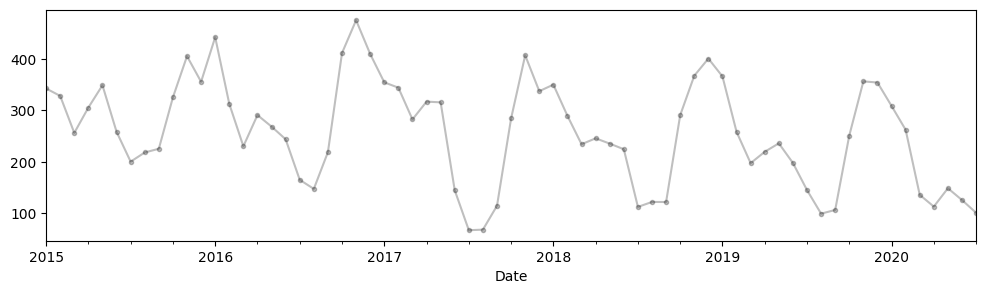

In [6]:
# Plotar série temporal do AQI
plot_params = {
    "style" : "k.-",
    "alpha" : 0.25,
    "figsize" : (12,3)
}
average_aqi.plot(**plot_params);

Dependendo de qual foi a cidade escolhida, podem haver poucos ou muitos dados faltantes. Então, é necessário lidar com eles para aplicar a regressão linear

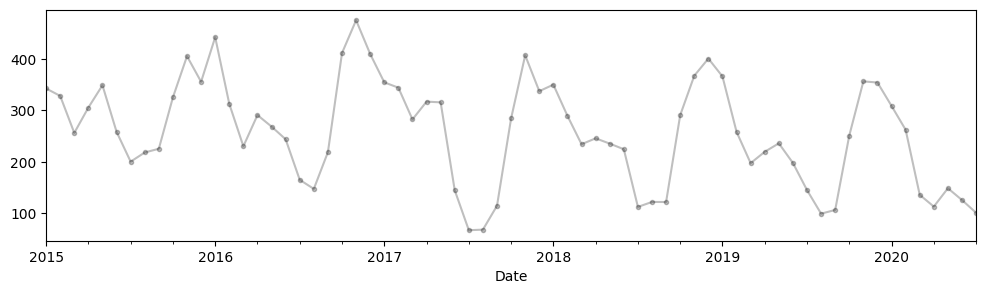

In [7]:
# Prencha os AQIs faltante com o valor que está imediatamente após ele
average_aqi = average_aqi.ffill(axis=0).fillna(0);

average_aqi.plot(**plot_params);

In [8]:
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Definir o rótulo (target)
y = average_aqi.copy()

# Instanciar o processo determinístico
dp = DeterministicProcess(
    index=y.index,
    order=3
)

# X contém as variáveis determinísticas (polinomiais) para as datas existentes na série y.
X = dp.in_sample()

# Cria a matriz com as mesmas colunas de X, mas para os próximos meses
X_fore = dp.out_of_sample(steps=12)

# Definir o modelo de regressão
# model = LinearRegression()
model = RandomForestRegressor(n_estimators=10, random_state=0, oob_score=True)
model.fit(X, y)

# Predição nos dados existentes
y_pred = pd.Series(model.predict(X), index=X.index)

# Prever as vendas para os próximos 90 dias com base na tendência polinomial aprendida.
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)


/home/rapha/.cache/pypoetry/virtualenvs/dca3501-project-NtdqnVCP-py3.12/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


In [9]:
# Avaliação do modelo
from sklearn.metrics import mean_squared_error, r2_score

# Métricas MSE e R2
print("Erro Quadrático Médio (MSE):", mean_squared_error(y, y_pred))
print("R²:", r2_score(y, y_pred))

Erro Quadrático Médio (MSE): 935.8309250483522
R²: 0.9069473708785989


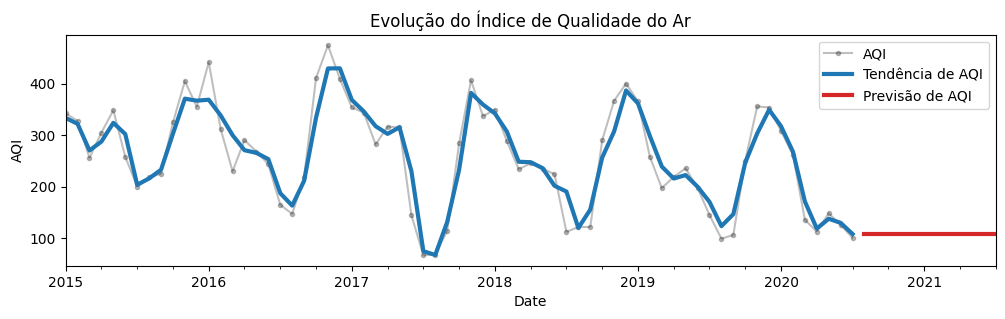

In [10]:
ax = y.plot(**plot_params, title="Evolução do Índice de Qualidade do Ar", ylabel="AQI")
ax = y_pred.plot(ax=ax, linewidth=3, label="Tendência de AQI", color='C0')
ax = y_fore.plot(ax=ax, linewidth=3, label="Previsão de AQI", color='C3')
ax.legend();

In [11]:
# Previsão de AQI médio para os próximos meses
diff = abs(average_aqi.iloc[-1] - y_fore.iloc[0]);

print(city)

print(f"AQI previsto de {y_fore.iloc[0]:.2f} no mês seguinte")

print(f"Diferença de {diff:.2f} em relação ao último mês")

Delhi
AQI previsto de 108.24 no mês seguinte
Diferença de 7.24 em relação ao último mês


In [12]:
import plotly.graph_objects as go

# Calcular a média móvel do AQI
aqi_trend = average_aqi.rolling(
    window=12,
    center=True,
    min_periods=6,
).mean()

# Converter índices Period para Timestamp (necessário para Plotly)
x_values = average_aqi.index.to_timestamp()
x_trend = aqi_trend.index.to_timestamp()

# Criar o gráfico
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_values,
    y=average_aqi.values,
    mode='lines',
    name='AQI',
    line=dict(color='lightgray'),
))

fig.add_trace(go.Scatter(
    x=x_trend,
    y=aqi_trend.values,
    mode='lines',
    name='Média Móvel',
    line=dict(color='blue', width=3),
))

fig.update_layout(
    title='Evolução do Índice de Qualidade do Ar',
    xaxis_title='Data',
    yaxis_title='AQI',
    legend=dict(x=0.01, y=0.99),
    template='plotly_white',
)

fig.show()

Exportar dataframe com séries temporais de cada cidade para ser utilizado no dashboard web

In [13]:
streamlit_data_path = Path('../streamlit/data')

data = air_quality[['AQI', 'City']]
data = data.to_period('M')
data = data.set_index(['City'], append=True)
data = data.ffill(axis=0).fillna(0);

aqi_city_average = data.groupby(by=['Date', 'City']).mean()['AQI']
aqi_city_average.to_csv(streamlit_data_path / "dashboard_aqi_time_series.csv")

Retornar apenas as linhas cujo Índice `City` seja uma cidade em específico

In [14]:
mask = aqi_city_average.index.get_level_values(level=1) == city
aqi_city_average.loc[mask].to_frame()

,,AQI
Date,City,
2015-01,Delhi,342.290323
2015-02,Delhi,327.928571
2015-03,Delhi,256.064516
2015-04,Delhi,305.266667
2015-05,Delhi,348.580645
...,...,...
2020-03,Delhi,135.838710
2020-04,Delhi,113.000000
2020-05,Delhi,148.645161
